In [1]:
# ============================================================================
# Ground truth  Phi^4_1   (Shi et al., Apendice F.1, Ec. 60)
#   dX_t = (Lap X_t + 3 X_t - X_t^3) dt + dW_t,   X_0 = chi0
#   ruido cilindrico Q=I (un browniano 1D por punto de grilla, proyectado a
#   sin(j pi x/L), j=1..Nx).  Solver IMEX: Lap implicito (Fourier) + reaccion explicita.
# ============================================================================
import numpy as np

# ---------------- Parametros (F.1) ----------------
L = 1.0  # dominio toro [0,1]
Nx = 128  # puntos de grilla
dx = L / Nx
dt = 1e-3  # paso temporal
T = 0.05  # tiempo final
Nt = int(round(T / dt))  # 50 pasos
sigma = 0.1  # intensidad global del ruido
x = np.arange(Nx) * dx
print(f"Nx={Nx} dx={dx} Nt={Nt} T={T} sigma={sigma}")

Nx=128 dx=0.0078125 Nt=50 T=0.05 sigma=0.1


In [2]:
# ---------------- Ruido Q-Browniano (cilindrico, Q=I) ----------------
def generar_ruido(rng, n_modes=Nx):
    """Incrementos espaciales dW (Nt,Nx).  dW^n(x) = sigma * sum_j dbeta_j phi_j(x),
    phi_j(x)=sqrt(2/L) sin(j pi x/L), dbeta_j ~ N(0,dt).  n_modes=Nx -> fiel a F.1."""
    j = np.arange(1, n_modes + 1)
    phi = np.sqrt(2.0 / L) * np.sin(np.outer(j, np.pi * x / L))  # (n_modes,Nx)
    dW = np.zeros((Nt, Nx))
    for n in range(Nt):
        dbeta = rng.standard_normal(n_modes) * np.sqrt(dt)
        dW[n] = sigma * (dbeta @ phi)
    return dW


# ---------------- Condiciones iniciales chi0 ----------------
def ci_cero():
    return np.zeros(Nx)  # tarea W->X


def ci_estocastica(rng, kappa=1.0, n_modes=10):
    """chi0 aleatoria = suma de senos con amplitud ~ 1/j^kappa.  (tarea (X0,W)->X)
    NOTA: kappa y esta forma NO los fija el paper -> decision de replica."""
    j = np.arange(1, n_modes + 1)
    coef = rng.standard_normal(n_modes) / j**kappa
    return coef @ np.sin(np.outer(j, np.pi * x / L))

In [3]:
# ---------------- Solver IMEX ----------------
# Lap periodico en Fourier: simbolo -k^2.  Paso: (I - dt Lap) X^{n+1} = X^n + dt(3X-X^3) + dW.
k = 2 * np.pi * np.fft.fftfreq(Nx, d=dx)
denom = 1.0 - dt * (-(k**2))  # (I - dt Lap) en Fourier


def resolver(X0, dW):
    """X0:(Nx,)  dW:(Nt,Nx)  ->  trayectoria (Nt+1,Nx)."""
    X = X0.copy()
    sol = np.zeros((Nt + 1, Nx))
    sol[0] = X
    for n in range(Nt):
        rhs = X + dt * (3.0 * X - X**3) + dW[n]  # reaccion explicita (Ec. 60)
        X = np.real(np.fft.ifft(np.fft.fft(rhs) / denom))  # paso implicito Lap
        sol[n + 1] = X
    return sol

In [4]:
# ---------------- Generador de dataset ----------------
def generar_dataset(N, seed, ci="cero", kappa=1.0):
    """Devuelve (W,X) con W:ruido ACUMULADO (N,Nt+1,Nx)  y  X:solucion (N,Nt+1,Nx)."""
    rng = np.random.default_rng(seed)
    W = np.zeros((N, Nt + 1, Nx))
    X = np.zeros((N, Nt + 1, Nx))
    for i in range(N):
        dW = generar_ruido(rng)
        X0 = ci_cero() if ci == "cero" else ci_estocastica(rng, kappa)
        X[i] = resolver(X0, dW)
        W[i, 1:] = np.cumsum(dW, axis=0)  # W(t,x) acumulado
    return W, X

In [5]:
# ---------------- Dataset oficial (tamanos del paper: 1000 train + 200 test) ----------------
N_TRAIN, N_TEST = 1000, 200
S_TR, S_TE = 2024, 7777  # semillas SEPARADAS train/test (no comparten ruido)


def guardar(fname, W_tr, X_tr, W_te, X_te, **extra):
    np.savez_compressed(
        fname,
        W_train=W_tr,
        X_train=X_tr,
        W_test=W_te,
        X_test=X_te,
        dx=dx,
        dt=dt,
        T=T,
        sigma=sigma,
        N_train=N_TRAIN,
        N_test=N_TEST,
        **extra,
    )
    print(f"guardado {fname} | train {X_tr.shape} test {X_te.shape}")


# Tarea 1:  W -> X   (chi0 = 0)
Wtr, Xtr = generar_dataset(N_TRAIN, S_TR, ci="cero")
Wte, Xte = generar_dataset(N_TEST, S_TE, ci="cero")
guardar("phi41_train_Wmap.npz", Wtr, Xtr, Wte, Xte, seed_train=S_TR, seed_test=S_TE)

# Tarea 2:  (X0,W) -> X   (chi0 estocastica; semillas +1 para no reusar ruidos)
Wtr2, Xtr2 = generar_dataset(N_TRAIN, S_TR + 1, ci="estocastica")
Wte2, Xte2 = generar_dataset(N_TEST, S_TE + 1, ci="estocastica")
guardar(
    "phi41_train_X0Wmap.npz",
    Wtr2,
    Xtr2,
    Wte2,
    Xte2,
    kappa=1.0,
    seed_train=S_TR + 1,
    seed_test=S_TE + 1,
)

guardado phi41_train_Wmap.npz | train (1000, 51, 128) test (200, 51, 128)
guardado phi41_train_X0Wmap.npz | train (1000, 51, 128) test (200, 51, 128)


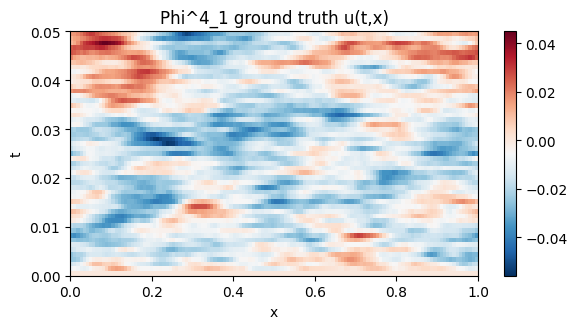

rango final: (np.float64(-0.0513), np.float64(0.0298))


In [6]:
# ---------------- (opcional) chequeo visual rapido ----------------
import matplotlib.pyplot as plt

sol = resolver(ci_cero(), generar_ruido(np.random.default_rng(0)))
fig, ax = plt.subplots(figsize=(6, 3.4))
im = ax.imshow(sol, aspect="auto", origin="lower", extent=[0, L, 0, T], cmap="RdBu_r")
ax.set_xlabel("x")
ax.set_ylabel("t")
ax.set_title("Phi^4_1 ground truth u(t,x)")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()
print("rango final:", (round(sol[-1].min(), 4), round(sol[-1].max(), 4)))